# VFA-1 — Main Experiment: Tabular Q vs. Linear FA across Grid Sizes

Trains three agents for **5 000 episodes** on grids of increasing size:
`10×10`, `20×20`, and `50×50`.  All plots are saved to `../../results/`.

**Scientific hypothesis:** tabular Q-learning degrades as grid size grows because
it cannot generalise across unseen states, while Linear FA maintains performance
by computing `phi(s,a)` for any state.

| Agent | Colour | Description |
|-------|--------|-------------|
| Tabular Q | blue | Dictionary Q-table; entries = unique (state, action) pairs seen |
| Linear FA — Simple | red | 5 hand-crafted features |
| Linear FA — Rich | green | 13 features (extends Simple with goal direction, wall density, …) |

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / 'src' / 'environment').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

RESULTS_DIR = root / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.environment.grid_world import FogGridWorld
from src.agents.tabular_q import TabularQAgent
from src.agents.linear_fa import LinearFAAgent
from src.features.feature_extractor import SimpleFeatureExtractor, RichFeatureExtractor

%matplotlib inline
plt.rcParams.update({
    'figure.dpi':    110,
    'savefig.dpi':   150,
    'savefig.bbox':  'tight',
})

## 1. Training

All nine runs share the same hyperparameters except `alpha`:
- **Tabular Q:** `alpha=0.1`  (each Q-entry is independent; a higher rate is safe)
- **Both FA agents:** `alpha=0.01`  (one update shifts every state's estimate)

The environment uses `fixed_map=False` (default) so each episode resets with a
fresh random layout.  Results are seeded per grid size for reproducibility.

In [2]:
N_TRAIN    = 5000
SMOOTH     = 100   # rolling-average window
GRID_SIZES = [10, 20, 50]

AGENT_CFG = [
    dict(label='Tabular Q',  color='steelblue', linestyle='-'),
    dict(label='Simple FA',  color='tomato',    linestyle='-'),
    dict(label='Rich FA',    color='seagreen',  linestyle='-'),
]

# results[grid][label] = {'rewards': [...], 'q_sizes': [...] (tabular only)}
results: dict = {}

for grid in GRID_SIZES:
    np.random.seed(42)   # reproducible epsilon-greedy decisions
    env = FogGridWorld(grid_size=grid)
    results[grid] = {}

    # ── Tabular Q ──────────────────────────────────────────────────────────
    agent_q = TabularQAgent(
        n_actions=env.action_space.n, alpha=0.1, gamma=0.99,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
    )
    q_rewards, q_sizes = [], []
    for ep in range(1, N_TRAIN + 1):
        obs, _ = env.reset()
        ep_r, done = 0.0, False
        while not done:
            a = agent_q.select_action(obs)
            nobs, r, term, trunc, _ = env.step(a)
            agent_q.update(obs, a, r, nobs, term)
            obs = nobs; ep_r += r; done = term or trunc
        agent_q.decay_epsilon()
        q_rewards.append(ep_r)
        q_sizes.append(agent_q.q_table_size)
    results[grid]['Tabular Q'] = {'rewards': q_rewards, 'q_sizes': q_sizes,
                                   'n_params': agent_q.q_table_size}
    print(f'[{grid:>2}×{grid:<2}] Tabular Q    last-100: {np.mean(q_rewards[-100:]):+.3f}'
          f'  entries: {agent_q.q_table_size:,}')

    # ── Simple FA ──────────────────────────────────────────────────────────
    agent_s = LinearFAAgent(
        n_actions=env.action_space.n, max_steps=env.max_steps,
        alpha=0.01, gamma=0.99,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
    )
    s_rewards = []
    for ep in range(1, N_TRAIN + 1):
        obs, _ = env.reset()
        ep_r, done = 0.0, False
        while not done:
            a = agent_s.select_action(obs)
            nobs, r, term, trunc, _ = env.step(a)
            agent_s.update(obs, a, r, nobs, term, trunc)
            obs = nobs; ep_r += r; done = term or trunc
        agent_s.decay_epsilon()
        s_rewards.append(ep_r)
    n_s = agent_s.feature_extractor.n_features
    results[grid]['Simple FA'] = {'rewards': s_rewards, 'n_params': n_s,
                                   'theta': agent_s.weights}
    print(f'[{grid:>2}×{grid:<2}] Simple FA    last-100: {np.mean(s_rewards[-100:]):+.3f}'
          f'  params: {n_s}')

    # ── Rich FA ────────────────────────────────────────────────────────────
    agent_r = LinearFAAgent(
        n_actions=env.action_space.n, max_steps=env.max_steps,
        alpha=0.01, gamma=0.99,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
        feature_extractor=RichFeatureExtractor(),
    )
    r_rewards = []
    for ep in range(1, N_TRAIN + 1):
        obs, _ = env.reset()
        ep_r, done = 0.0, False
        while not done:
            a = agent_r.select_action(obs)
            nobs, r, term, trunc, _ = env.step(a)
            agent_r.update(obs, a, r, nobs, term, trunc)
            obs = nobs; ep_r += r; done = term or trunc
        agent_r.decay_epsilon()
        r_rewards.append(ep_r)
    n_r = agent_r.feature_extractor.n_features
    results[grid]['Rich FA'] = {'rewards': r_rewards, 'n_params': n_r,
                                 'theta': agent_r.weights}
    print(f'[{grid:>2}×{grid:<2}] Rich FA      last-100: {np.mean(r_rewards[-100:]):+.3f}'
          f'  params: {n_r}')
    print()

[10×10] Tabular Q    last-100: -1.709  entries: 756,540


[10×10] Simple FA    last-100: -0.985  params: 5


[10×10] Rich FA      last-100: -0.887  params: 13



[20×20] Tabular Q    last-100: -1.768  entries: 620,318


[20×20] Simple FA    last-100: -1.010  params: 5


[20×20] Rich FA      last-100: -0.973  params: 13



[50×50] Tabular Q    last-100: -1.653  entries: 507,736


[50×50] Simple FA    last-100: -1.042  params: 5


[50×50] Rich FA      last-100: -1.005  params: 13



## 2. Per-grid learning curves

One figure per grid size.  **Top panel:** 100-episode rolling average of episode
reward.  **Bottom panel:** Q-table entries (tabular, blue) vs. the fixed parameter
counts of the two FA agents (dashed/dotted horizontal lines).

Saved → /Users/tobiasbronold/Documents/UniMi-coding/UniMi-RL-project/vfa1_navigating_fog/results/grid_10x10_comparison.png


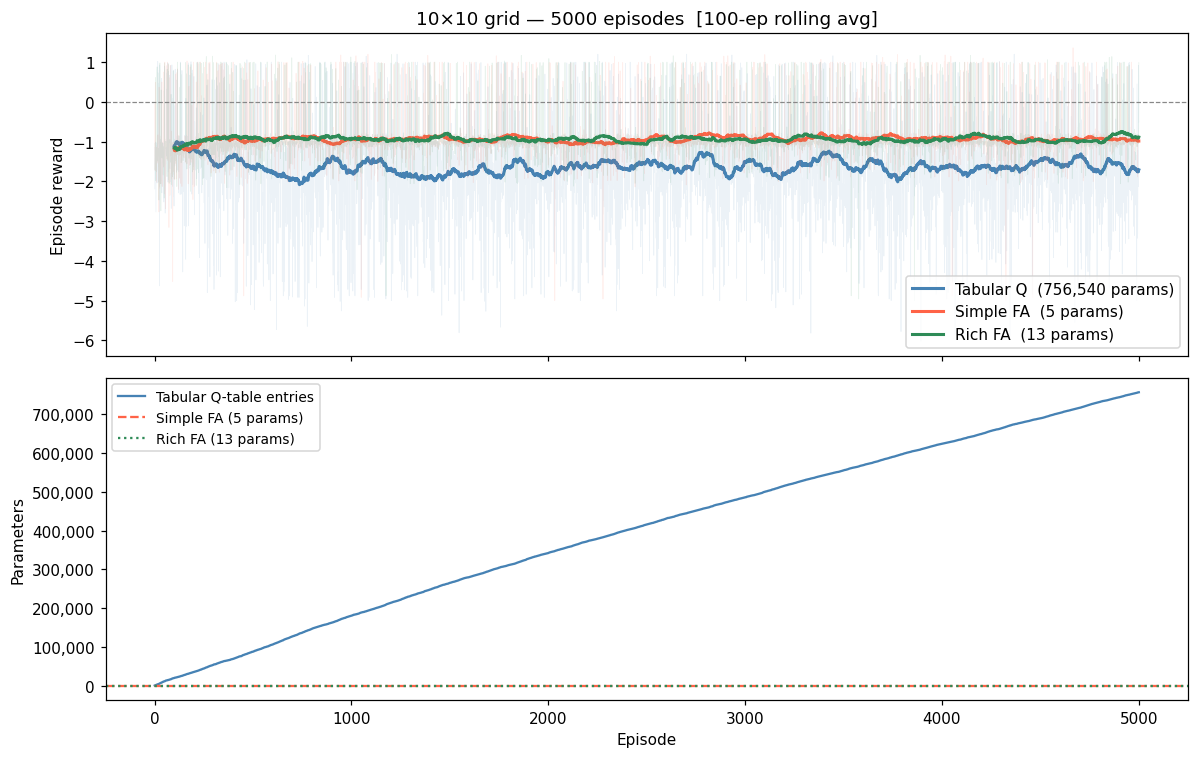

Saved → /Users/tobiasbronold/Documents/UniMi-coding/UniMi-RL-project/vfa1_navigating_fog/results/grid_20x20_comparison.png


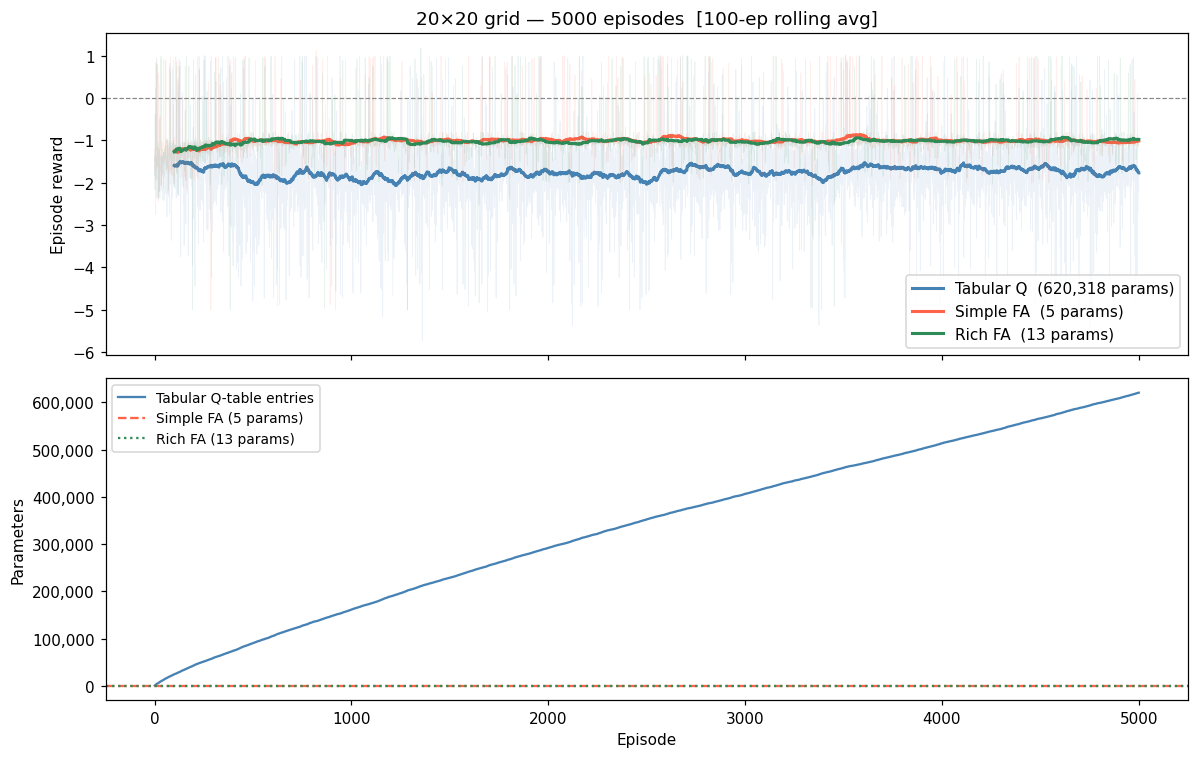

Saved → /Users/tobiasbronold/Documents/UniMi-coding/UniMi-RL-project/vfa1_navigating_fog/results/grid_50x50_comparison.png


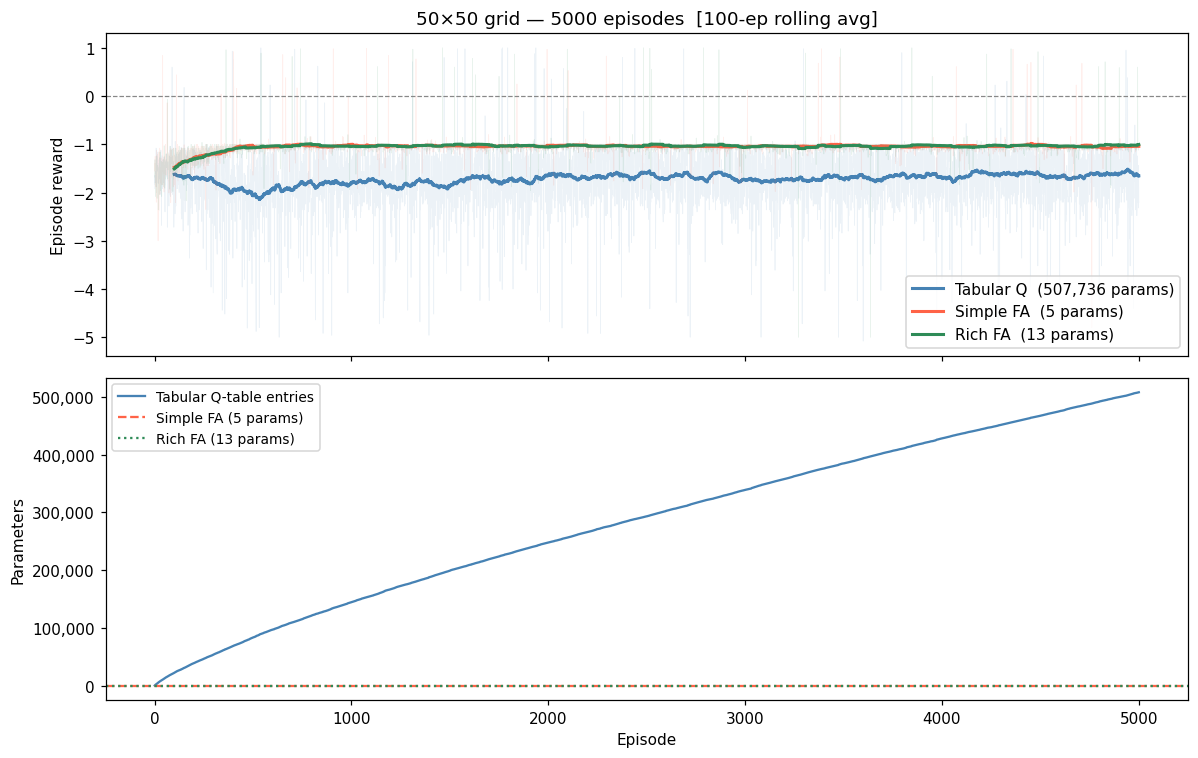

In [3]:
episodes = np.arange(1, N_TRAIN + 1)
kernel   = np.ones(SMOOTH) / SMOOTH
x_smooth = episodes[SMOOTH - 1:]

for grid in GRID_SIZES:
    res  = results[grid]
    fig, (ax_r, ax_p) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    # ── Reward panel ────────────────────────────────────────────────────────
    for label, color in [('Tabular Q','steelblue'),('Simple FA','tomato'),('Rich FA','seagreen')]:
        rw = res[label]['rewards']
        n  = res[label]['n_params']
        ax_r.plot(episodes, rw, alpha=0.10, color=color, linewidth=0.5)
        smooth = np.convolve(rw, kernel, mode='valid')
        param_str = f'{n:,}' if label == 'Tabular Q' else str(n)
        ax_r.plot(x_smooth, smooth, color=color, linewidth=2.0,
                  label=f'{label}  ({param_str} params)')

    ax_r.axhline(0, color='#888', linestyle='--', linewidth=0.8)
    ax_r.set_ylabel('Episode reward')
    ax_r.legend(loc='lower right', fontsize=10)
    ax_r.set_title(
        f'{grid}×{grid} grid — {N_TRAIN} episodes  [{SMOOTH}-ep rolling avg]',
        fontsize=12,
    )

    # ── Parameter count panel ────────────────────────────────────────────────
    ax_p.plot(episodes, res['Tabular Q']['q_sizes'],
              color='steelblue', linewidth=1.5, label='Tabular Q-table entries')
    n_s = res['Simple FA']['n_params']
    n_r = res['Rich FA']['n_params']
    ax_p.axhline(n_s, color='tomato',   linewidth=1.5, linestyle='--',
                 label=f'Simple FA ({n_s} params)')
    ax_p.axhline(n_r, color='seagreen', linewidth=1.5, linestyle=':',
                 label=f'Rich FA ({n_r} params)')
    ax_p.set_ylabel('Parameters')
    ax_p.set_xlabel('Episode')
    ax_p.legend(fontsize=9)
    ax_p.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    plt.tight_layout()
    path = RESULTS_DIR / f'grid_{grid}x{grid}_comparison.png'
    fig.savefig(path)
    print(f'Saved → {path}')
    plt.show()

## 3. Summary: performance vs. grid size

How does each agent's final quality (last-100-episode average reward) change as
the grid grows?  This is the core comparison of the VFA-1 project.

Saved → /Users/tobiasbronold/Documents/UniMi-coding/UniMi-RL-project/vfa1_navigating_fog/results/summary_performance_vs_gridsize.png


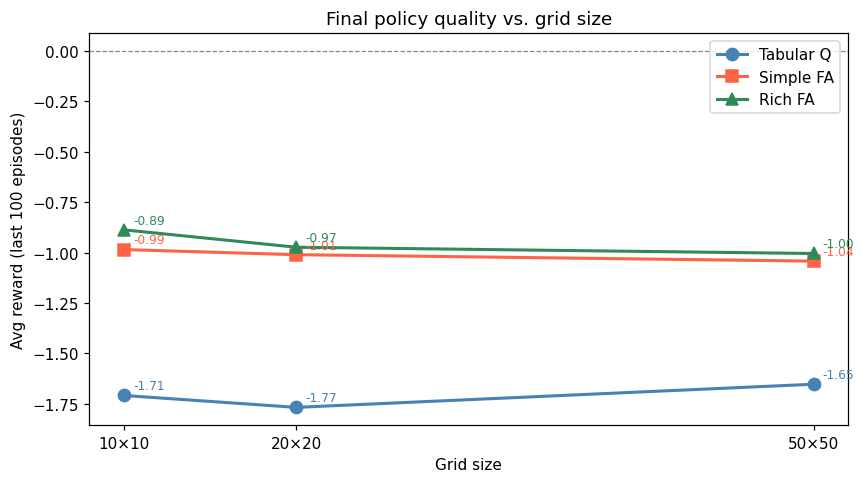

In [4]:
labels  = ['Tabular Q', 'Simple FA', 'Rich FA']
colors  = ['steelblue', 'tomato', 'seagreen']
markers = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(8, 4.5))

for label, color, marker in zip(labels, colors, markers):
    final_avgs = [
        float(np.mean(results[g][label]['rewards'][-100:]))
        for g in GRID_SIZES
    ]
    ax.plot(GRID_SIZES, final_avgs,
            color=color, marker=marker, linewidth=2.0, markersize=8,
            label=label)
    for g, v in zip(GRID_SIZES, final_avgs):
        ax.annotate(f'{v:+.2f}', (g, v),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, color=color)

ax.axhline(0, color='#888', linestyle='--', linewidth=0.8)
ax.set_xticks(GRID_SIZES)
ax.set_xticklabels([f'{g}×{g}' for g in GRID_SIZES])
ax.set_xlabel('Grid size')
ax.set_ylabel('Avg reward (last 100 episodes)')
ax.set_title('Final policy quality vs. grid size', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
path = RESULTS_DIR / 'summary_performance_vs_gridsize.png'
fig.savefig(path)
print(f'Saved → {path}')
plt.show()

## 4. Summary table

In [5]:
rows = []
for grid in GRID_SIZES:
    for label in labels:
        d = results[grid][label]
        last100 = float(np.mean(d['rewards'][-100:]))
        last500 = float(np.mean(d['rewards'][-500:]))
        n = d['n_params']
        param_str = f"{n:,}" if label == 'Tabular Q' else str(n)
        rows.append({
            'Grid':        f'{grid}×{grid}',
            'Agent':       label,
            'Parameters':  param_str,
            'Last-100 avg': f'{last100:+.4f}',
            'Last-500 avg': f'{last500:+.4f}',
        })

df = pd.DataFrame(rows)
df.index = pd.RangeIndex(1, len(df) + 1)
display(df)

csv_path = RESULTS_DIR / 'summary_table.csv'
df.to_csv(csv_path, index=False)
print(f'\nSaved → {csv_path}')

,Grid,Agent,Parameters,Last-100 avg,Last-500 avg
1,10×10,Tabular Q,"756,540",-1.7087,-1.5965
2,10×10,Simple FA,5,-0.9851,-0.9519
3,10×10,Rich FA,13,-0.8871,-0.9317
4,20×20,Tabular Q,"620,318",-1.7678,-1.7304
5,20×20,Simple FA,5,-1.0104,-1.0217
6,20×20,Rich FA,13,-0.9734,-0.9879
7,50×50,Tabular Q,"507,736",-1.6530,-1.6464
8,50×50,Simple FA,5,-1.0423,-1.0503
9,50×50,Rich FA,13,-1.0045,-1.0287



Saved → /Users/tobiasbronold/Documents/UniMi-coding/UniMi-RL-project/vfa1_navigating_fog/results/summary_table.csv


## 5. Learned weights — how theta evolves with grid size

Because Linear FA uses a fixed feature vector, the learned `theta` has the same
meaning regardless of grid size.  Comparing theta across grid sizes reveals which
features become more or less informative as the environment grows.

Saved → /Users/tobiasbronold/Documents/UniMi-coding/UniMi-RL-project/vfa1_navigating_fog/results/learned_weights_by_grid.png


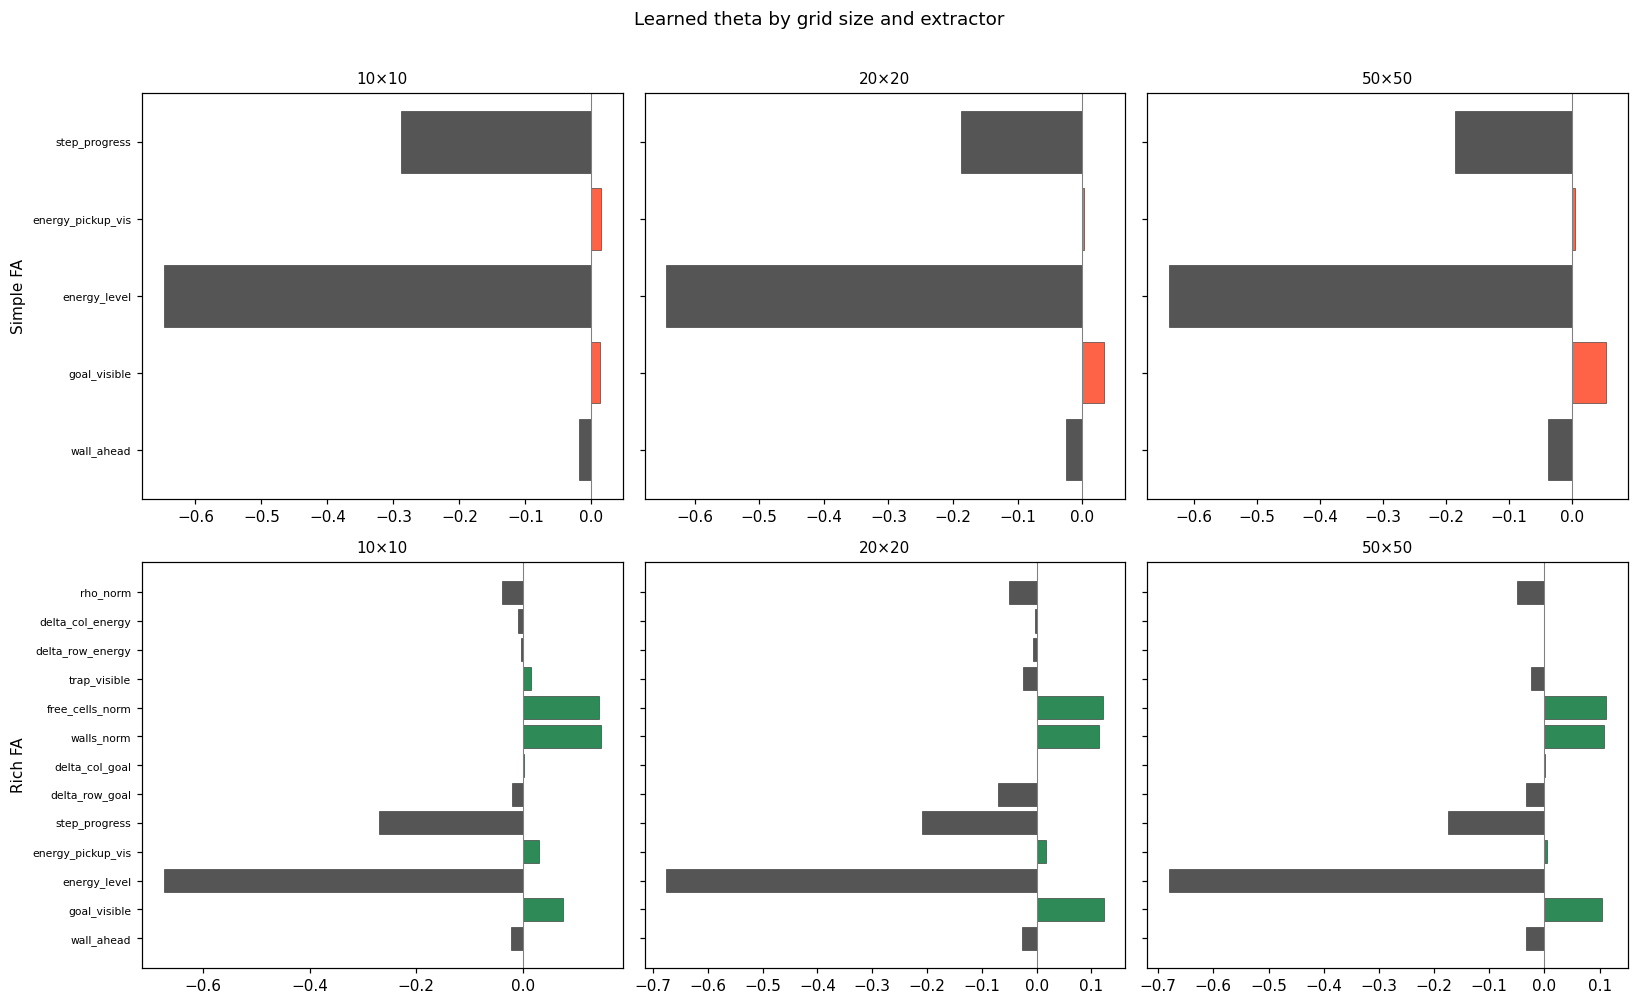

In [6]:
simple_names = [
    'wall_ahead', 'goal_visible', 'energy_level',
    'energy_pickup_vis', 'step_progress',
]
rich_names = simple_names + [
    'delta_row_goal', 'delta_col_goal',
    'walls_norm', 'free_cells_norm',
    'trap_visible',
    'delta_row_energy', 'delta_col_energy',
    'rho_norm',
]

fig, axes = plt.subplots(
    2, len(GRID_SIZES),
    figsize=(5 * len(GRID_SIZES), 9),
    sharey='row',
)

for col, grid in enumerate(GRID_SIZES):
    for row, (agent_label, feat_names, bar_color) in enumerate([
        ('Simple FA', simple_names, 'tomato'),
        ('Rich FA',   rich_names,   'seagreen'),
    ]):
        ax = axes[row, col]
        theta = results[grid][agent_label]['theta']
        bar_colors = [bar_color if w >= 0 else '#555' for w in theta]
        ax.barh(feat_names, theta, color=bar_colors, edgecolor='#333', linewidth=0.4)
        ax.axvline(0, color='gray', linewidth=0.7)
        if col == 0:
            ax.set_ylabel(agent_label, fontsize=10)
        ax.set_title(f'{grid}×{grid}', fontsize=10)
        ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Learned theta by grid size and extractor', fontsize=12, y=1.01)
plt.tight_layout()
path = RESULTS_DIR / 'learned_weights_by_grid.png'
fig.savefig(path)
print(f'Saved → {path}')
plt.show()